# 03 Train LSTM (Full Feature) for TSI

This notebook trains an LSTM model for Trophic State Index (TSI)
using a full feature set:
- TSI
- Chlorophyll-a
- Secchi Depth

This model is implemented as an advanced research model
based on Arsanchai et al. (2025).


Cell 2: Import Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


Cell 3: Paths

In [5]:
DATA_DIR = "../data_prepared"
MODEL_DIR = "../models_lstm"
RESULT_DIR = "../results_lstm"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


Cell 4: Create Supervised Dataset

In [6]:
def create_lstm_dataset(data, look_back=6):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back, :])
        y.append(data[i+look_back, 0])  # TSI as target
    return np.array(X), np.array(y)


Cell 5: Train/Test Split (Time-based)

In [7]:
def train_test_split_lstm(X, y, train_ratio=0.8):
    split = int(len(X) * train_ratio)
    return X[:split], X[split:], y[:split], y[split:]

Cell 6: Loop Training All Stations

In [8]:
summary = []

for file in os.listdir(DATA_DIR):
    if not file.endswith("_prepared.csv"):
        continue

    station = file.split("_")[0]
    print(f"\n🔹 Training LSTM for station: {station}")

    df = pd.read_csv(
        os.path.join(DATA_DIR, file),
        index_col="Date",
        parse_dates=True
    )

    # Full feature set
    features = df[["TSI", "Chlorophyll_a", "Secchi_Depth"]].values

    # Scaling
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(features)

    # Create supervised dataset
    X, y = create_lstm_dataset(scaled, look_back=6)
    X_train, X_test, y_train, y_test = train_test_split_lstm(X, y)

    # Build LSTM model
    model = Sequential([
        LSTM(64, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

    # Prediction
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    model.save(f"{MODEL_DIR}/{station}_lstm_tsi.h5")

    summary.append([station, rmse, mae])



🔹 Training LSTM for station: CP01


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step



🔹 Training LSTM for station: LS01


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step



🔹 Training LSTM for station: TP04


D:\I-New Gen _Aquasign\Model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


Cell 7: Results Summary

In [9]:
summary_df = pd.DataFrame(
    summary,
    columns=["Station", "TSI_LSTM_RMSE", "TSI_LSTM_MAE"]
)

summary_df.to_csv(f"{RESULT_DIR}/lstm_tsi_evaluation.csv", index=False)
summary_df

,Station,TSI_LSTM_RMSE,TSI_LSTM_MAE
0,CP01,0.105165,0.091156
1,LS01,0.153006,0.124618
2,LS03,0.105749,0.085691
3,PN01,0.163107,0.127291
4,SK01,0.247899,0.219173
5,SK06,0.117216,0.105501
6,TP011,0.115012,0.083304
7,TP01,0.109589,0.084368
8,TP04,0.108768,0.090259


Cell 8: Plot Example

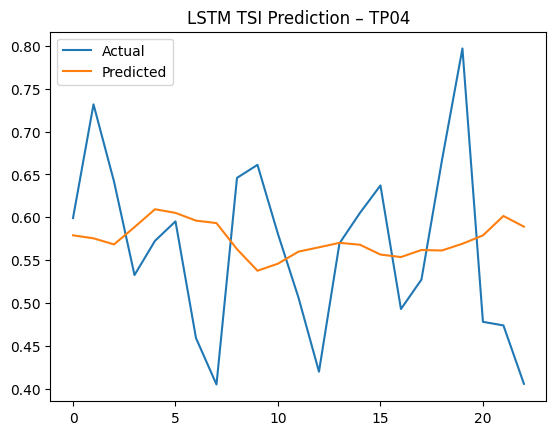

In [10]:
plt.figure()
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title(f"LSTM TSI Prediction – {station}")
plt.show()
